In [23]:
!pip install Faker

In [27]:
!pip install pandas

In [3]:
#¿Porque una empresa podria no compartir sus datos reales?

In [4]:
#¿Que sesgos existen al utilizar informacion personal de clientes?

In [25]:
#¿Crees que es posible entrenar un modelo de ML sin utilizar datos reales?

In [32]:
#Importamos librerias
from faker import Faker
import pandas as pd
import random

In [33]:
#Creamos una instancia de faker
fake = Faker("es_MX")

In [75]:
#generamos datos sintaticos:100 registros
datos = []
for i in range(1000):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18,65),
        "seguidores": random.randint(100, 50000),
        "plataforma": random.choice(
        ["TikTok", "Instagram", "Youtube"]
    )
})

In [76]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Carolina Benavídez,zveliz@example.net,18,7314,TikTok
1,2,Wendolin Rendón Piña,sandramanzanares@example.com,48,15831,Youtube
2,3,Lorenzo Colunga,uriel71@example.com,37,11055,TikTok
3,4,Sr. Humberto Sánchez,ksalinas@example.net,22,9924,TikTok
4,5,Lic. Genaro Gallardo,porfirio18@example.org,51,46111,TikTok


In [77]:
#Exploracion del Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  1000 non-null   int64 
 1   nombre      1000 non-null   object
 2   correo      1000 non-null   object
 3   edad        1000 non-null   int64 
 4   seguidores  1000 non-null   int64 
 5   plataforma  1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [78]:
#Estadistica descriptiva
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.000000,1000,1000,1000.000000,1000.000000,1000
unique,NaN,1000,1000,NaN,NaN,3
top,NaN,Carolina Benavídez,zveliz@example.net,NaN,NaN,TikTok
freq,NaN,1,1,NaN,NaN,356
mean,500.500000,NaN,NaN,42.047000,25135.977000,NaN
std,288.819436,NaN,NaN,13.829897,14389.132294,NaN
min,1.000000,NaN,NaN,18.000000,121.000000,NaN
25%,250.750000,NaN,NaN,31.000000,12594.250000,NaN
50%,500.500000,NaN,NaN,43.000000,25456.000000,NaN
75%,750.250000,NaN,NaN,54.000000,37840.000000,NaN


In [80]:
#importar librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

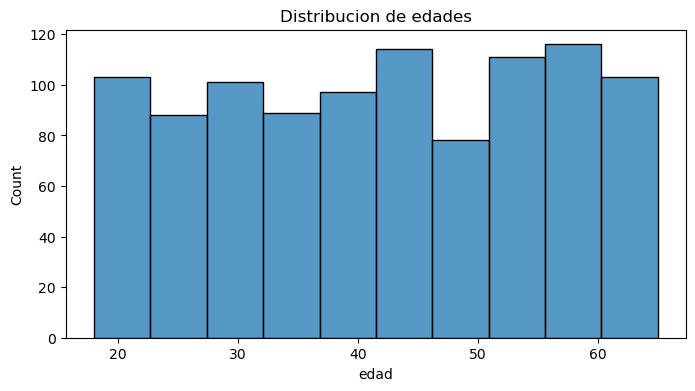

In [81]:
#Distribucion de edades
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribucion de edades")
plt.show()

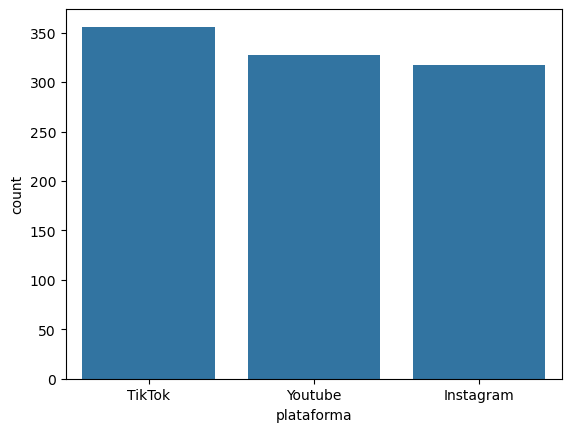

In [82]:
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [83]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [84]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"nombre"] = None

In [85]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  1000 non-null   int64 
 1   nombre      995 non-null    object
 2   correo      1000 non-null   object
 3   edad        1000 non-null   int64 
 4   seguidores  1000 non-null   int64 
 5   plataforma  1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [86]:
#edades inválidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "edad"] = -10

In [87]:
df_sucio.describe()["edad"]

count    1000.000000
mean       41.820000
std        14.273378
min       -10.000000
25%        30.000000
50%        43.000000
75%        54.000000
max        65.000000
Name: edad, dtype: float64

In [89]:
#Seguidores imposibles
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i,"seguidores"]= 5000000

In [90]:
df_sucio.describe()["seguidores"]

count    1.000000e+03
mean     7.490121e+04
std      4.954449e+05
min      1.210000e+02
25%      1.270825e+04
50%      2.603500e+04
75%      3.806750e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [91]:
#Generamos correos invalidos
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i,"correo"]= "correo_invalido"

In [93]:
df_sucio.describe(include=["string","object"])

,nombre,correo,plataforma
count,995,1000,1000
unique,995,996,3
top,Carolina Benavídez,correo_invalido,TikTok
freq,1,5,356


In [94]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [97]:
pd.set_option('display.float_format',lambda x: '%.2f' % x)

In [98]:
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.00,995,1000,1000.00,1000.00,1000
unique,NaN,995,996,NaN,NaN,3
top,NaN,Carolina Benavídez,correo_invalido,NaN,NaN,TikTok
freq,NaN,1,5,NaN,NaN,356
mean,500.50,NaN,NaN,41.82,74901.21,NaN
std,288.82,NaN,NaN,14.27,495444.95,NaN
min,1.00,NaN,NaN,-10.00,121.00,NaN
25%,250.75,NaN,NaN,30.00,12708.25,NaN
50%,500.50,NaN,NaN,43.00,26035.00,NaN
75%,750.25,NaN,NaN,54.00,38067.50,NaN
